# NB04: AlphaEarth Continuous Environment Analysis

Use continuous environmental embeddings (64-dim AlphaEarth) instead of discrete
environment categories to test whether AMR profile distance correlates with
environmental distance.

**Caveat**: Only 28% genome coverage, biased toward environmental samples.
Filter NaN embeddings (4.6%). Stratify human-associated vs environmental.

**Inputs:** `data/species_amr_profiles.csv`, AlphaEarth embeddings (Spark)

**Outputs:** `data/alphaearth_amr_analysis.csv`, figures

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import pdist, squareform, cosine

warnings.filterwarnings('ignore', category=FutureWarning)

_here = os.path.abspath('')
if os.path.basename(_here) == 'notebooks':
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))
elif os.path.exists(os.path.join(_here, 'projects', 'amr_environmental_resistome')):
    REPO = _here
else:
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))

PROJECT = os.path.join(REPO, 'projects', 'amr_environmental_resistome')
DATA = os.path.join(PROJECT, 'data')
FIGURES = os.path.join(PROJECT, 'figures')

# Load species AMR profiles
sp = pd.read_csv(os.path.join(DATA, 'species_amr_profiles.csv'))
sp['no_genomes'] = pd.to_numeric(sp['no_genomes'], errors='coerce')
print(f'Species with AMR data: {len(sp):,}')

Species with AMR data: 14,723


## 1. Extract species-level AlphaEarth embeddings

In [2]:
# Load AlphaEarth embeddings — compute species-level mean embedding
from berdl_notebook_utils.setup_spark_session import get_spark_session
spark = get_spark_session()

# Embedding columns are A00-A63 (64 dimensions)
emb_col_list = ', '.join([f'ae.A{i:02d}' for i in range(64)])

ae = spark.sql(f"""
    SELECT g.gtdb_species_clade_id, ae.genome_id,
           {emb_col_list}
    FROM kbase_ke_pangenome.alphaearth_embeddings_all_years ae
    JOIN kbase_ke_pangenome.genome g ON ae.genome_id = g.genome_id
""").toPandas()

print(f'Genomes with embeddings: {len(ae):,}')
print(f'Species represented: {ae["gtdb_species_clade_id"].nunique():,}')

# Embedding columns
emb_cols = [f'A{i:02d}' for i in range(64)]
print(f'Embedding dimensions: {len(emb_cols)}')

# Filter NaN embeddings
for c in emb_cols:
    ae[c] = pd.to_numeric(ae[c], errors='coerce')
valid_mask = ~ae[emb_cols].isna().any(axis=1)
ae_clean = ae[valid_mask].copy()
print(f'After NaN filter: {len(ae_clean):,} genomes ({valid_mask.mean()*100:.1f}% retained)')


Genomes with embeddings: 83,287
Species represented: 15,046
Embedding dimensions: 64
After NaN filter: 79,449 genomes (95.4% retained)


In [3]:
# Species-level mean embedding (for species with >=3 genomes with embeddings)
species_emb = ae_clean.groupby('gtdb_species_clade_id')[emb_cols].mean()
species_genome_count = ae_clean.groupby('gtdb_species_clade_id').size()
species_emb = species_emb[species_genome_count >= 3]

print(f'Species with mean embeddings (>=3 genomes): {len(species_emb):,}')

# Merge with AMR data
sp_slim = sp.drop(columns=[c for c in ['phylum', 'class', 'order', 'family', 'genus'] if c in sp.columns])
ae_amr = sp_slim.set_index('gtdb_species_clade_id').join(species_emb, how='inner')
ae_amr = ae_amr[ae_amr['species_environment'].notna()].copy()
print(f'Species with AMR + embeddings + environment: {len(ae_amr):,}')

Species with mean embeddings (>=3 genomes): 4,521
Species with AMR + embeddings + environment: 2,659


## 2. AMR diversity vs embedding dimensions

In [4]:
from statsmodels.stats.multitest import multipletests

# Correlate each embedding dimension with AMR diversity
corr_results = []
for col in emb_cols:
    r, p = stats.spearmanr(ae_amr[col], ae_amr['n_amr_clusters'])
    corr_results.append({'dimension': col, 'rho': r, 'p_value': p})

corr_df = pd.DataFrame(corr_results)
_, q, _, _ = multipletests(corr_df['p_value'], method='fdr_bh')
corr_df['q_value'] = q
corr_df['significant'] = q < 0.05

print(f'Embedding dimensions tested: {len(corr_df)}')
print(f'Significant (FDR<0.05): {corr_df["significant"].sum()}')
print(f'\nTop correlated dimensions:')
for _, row in corr_df.nlargest(10, 'rho').iterrows():
    sig = '*' if row['significant'] else ''
    print(f'  {row["dimension"]:10s}: rho={row["rho"]:+.4f}, q={row["q_value"]:.4g} {sig}')

print(f'\nMost anti-correlated:')
for _, row in corr_df.nsmallest(5, 'rho').iterrows():
    sig = '*' if row['significant'] else ''
    print(f'  {row["dimension"]:10s}: rho={row["rho"]:+.4f}, q={row["q_value"]:.4g} {sig}')

Embedding dimensions tested: 64
Significant (FDR<0.05): 52

Top correlated dimensions:
  A34       : rho=+0.2391, q=4.585e-34 *
  A24       : rho=+0.2335, q=9.341e-33 *
  A56       : rho=+0.2094, q=1.239e-26 *
  A17       : rho=+0.2080, q=2.082e-26 *
  A19       : rho=+0.2023, q=4.13e-25 *
  A51       : rho=+0.1851, q=3.191e-21 *
  A02       : rho=+0.1706, q=3.132e-18 *
  A27       : rho=+0.1658, q=2.749e-17 *
  A44       : rho=+0.1574, q=1.02e-15 *
  A25       : rho=+0.1568, q=1.279e-15 *

Most anti-correlated:
  A63       : rho=-0.2150, q=7.371e-28 *
  A32       : rho=-0.2141, q=9.639e-28 *
  A62       : rho=-0.2089, q=1.432e-26 *
  A55       : rho=-0.2058, q=6.393e-26 *
  A36       : rho=-0.2004, q=1.091e-24 *


## 3. Mantel test: embedding distance vs AMR distance

In [5]:
# Subsample for Mantel test — filter species with >0 AMR mechanism counts
np.random.seed(42)

# Filter species with at least 1 AMR cluster in mechanism columns
amr_cols = ['n_efflux', 'n_enzymatic', 'n_metal', 'n_target_mod', 'n_other_mech']
ae_amr_valid = ae_amr[ae_amr[amr_cols].fillna(0).sum(axis=1) > 0].copy()
n_sample = min(500, len(ae_amr_valid))
sample_idx = np.random.choice(len(ae_amr_valid), n_sample, replace=False)
ae_sample = ae_amr_valid.iloc[sample_idx]

# Embedding distance (cosine)
emb_matrix = ae_sample[emb_cols].values
emb_dist = pdist(emb_matrix, metric='cosine')

# AMR distance: use mechanism fractions as profile
amr_matrix = ae_sample[amr_cols].fillna(0).values
# Normalize to fractions
row_sums = amr_matrix.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
amr_frac = amr_matrix / row_sums
amr_dist = pdist(amr_frac, metric='braycurtis')

# Filter any NaN distances
valid_pairs = np.isfinite(emb_dist) & np.isfinite(amr_dist)
emb_dist_clean = emb_dist[valid_pairs]
amr_dist_clean = amr_dist[valid_pairs]

# Mantel test (Spearman)
observed_r, _ = stats.spearmanr(emb_dist_clean, amr_dist_clean)

n_perm = 999
perm_rs = []
for _ in range(n_perm):
    perm_idx = np.random.permutation(n_sample)
    amr_perm = pdist(amr_frac[perm_idx], metric='braycurtis')
    amr_perm_clean = amr_perm[valid_pairs]
    if np.all(np.isfinite(amr_perm_clean)):
        r_perm, _ = stats.spearmanr(emb_dist_clean, amr_perm_clean)
        if np.isfinite(r_perm):
            perm_rs.append(r_perm)

p_mantel = (np.sum(np.array(perm_rs) >= observed_r) + 1) / (len(perm_rs) + 1) if perm_rs else 1.0

print(f'=== Mantel test: embedding distance vs AMR distance ===')
print(f'Sample size: {n_sample} species ({valid_pairs.sum():,} valid distance pairs)')
print(f'Observed Spearman r = {observed_r:.4f}')
print(f'Permutation p = {p_mantel:.4f} ({len(perm_rs)} valid permutations)')


=== Mantel test: embedding distance vs AMR distance ===
Sample size: 500 species (124,750 valid distance pairs)
Observed Spearman r = 0.0980
Permutation p = 0.0010 (999 valid permutations)


In [6]:
# Stratify by environment type
for env_type, label in [('clinical', 'Clinical species'),
                          ('soil', 'Soil species'),
                          ('aquatic', 'Aquatic species')]:
    env_data = ae_amr[ae_amr['species_environment'] == env_type]
    if len(env_data) < 30:
        print(f'{label}: N={len(env_data)}, too small')
        continue
    
    n_sub = min(200, len(env_data))
    sub_idx = np.random.choice(len(env_data), n_sub, replace=False)
    sub = env_data.iloc[sub_idx]
    
    e_dist = pdist(sub[emb_cols].values, metric='cosine')
    a_matrix = sub[amr_cols].fillna(0).values
    rs = a_matrix.sum(axis=1, keepdims=True)
    rs[rs == 0] = 1
    a_dist = pdist(a_matrix / rs, metric='braycurtis')
    
    r_obs, _ = stats.spearmanr(e_dist, a_dist)
    print(f'{label:20s}: N={n_sub}, Mantel r={r_obs:.4f}')

Clinical species    : N=200, Mantel r=0.1770
Soil species        : N=200, Mantel r=0.1294
Aquatic species     : N=200, Mantel r=0.0609


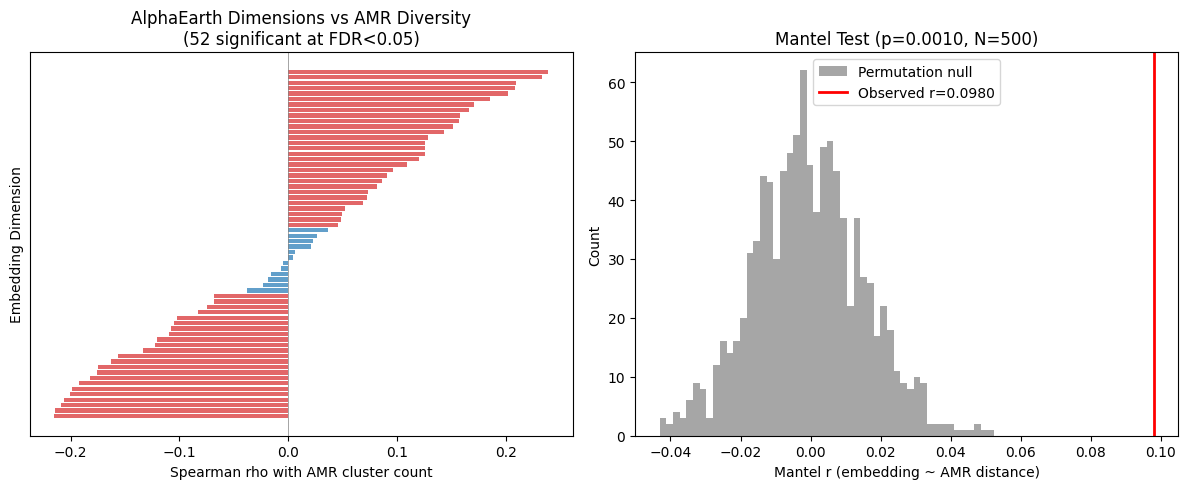

Saved to figures/nb04_alphaearth.png


In [7]:
# Figure: embedding dim correlations with AMR
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: correlation coefficients by dimension
ax = axes[0]
sorted_corr = corr_df.sort_values('rho')
colors = ['tab:red' if s else 'tab:blue' for s in sorted_corr['significant']]
ax.barh(range(len(sorted_corr)), sorted_corr['rho'], color=colors, alpha=0.7)
ax.set_xlabel('Spearman rho with AMR cluster count')
ax.set_ylabel('Embedding Dimension')
ax.set_title(f'AlphaEarth Dimensions vs AMR Diversity\n'
             f'({corr_df["significant"].sum()} significant at FDR<0.05)')
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_yticks([])

# Right: Mantel test null distribution
ax = axes[1]
perm_rs_clean = [r for r in perm_rs if np.isfinite(r)]
ax.hist(perm_rs_clean, bins=50, alpha=0.7, color='gray', label='Permutation null')
ax.axvline(observed_r, color='red', linewidth=2, label=f'Observed r={observed_r:.4f}')
ax.set_xlabel('Mantel r (embedding ~ AMR distance)')
ax.set_ylabel('Count')
ax.set_title(f'Mantel Test (p={p_mantel:.4f}, N={n_sample})')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'nb04_alphaearth.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved to figures/nb04_alphaearth.png')

In [8]:
# Save
corr_df.to_csv(os.path.join(DATA, 'alphaearth_amr_correlations.csv'), index=False)

print(f'=== NB04 Summary ===')
print(f'Species with AMR + embeddings: {len(ae_amr):,}')
print(f'Embedding dims correlated with AMR (FDR<0.05): {corr_df["significant"].sum()}/{len(corr_df)}')
print(f'Mantel test (embedding ~ AMR distance): r={observed_r:.4f}, p={p_mantel:.4f}')

=== NB04 Summary ===
Species with AMR + embeddings: 2,659
Embedding dims correlated with AMR (FDR<0.05): 52/64
Mantel test (embedding ~ AMR distance): r=0.0980, p=0.0010
